# NGPS Radial Velocity Tutorial

In this notebook, we show how to derive robust radial velocities (RVs) from Next Generation Palomar Spectrograph (NGPS) 2D spectra produced by the QuickLook Data Reduction Pipeline. In particular, using a 0.5" slit observation of an RV standard star as an example, we show how to derive flexure corrections from telluric lines and apply them to measure RVs in the G, R, and I channels. Here, "flexure" refers to shifts in the wavelength solution induced by motion of the NGPS instrument between observations. We show that this approach recovers the known RVs of standard stars to within a precision of less than 5 km s$^{-1}$, and provide a command-line script to apply our method (described in Nagarajan & El-Badry in prep) to science targets with unknown RVs.

In [1]:
# Import necessary packages
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

warnings.filterwarnings("ignore")

try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
    set_matplotlib_formats("svg")
except Exception:
    pass

try:
    import scienceplots
    plt.style.use(["science", "no-latex"])
except Exception:
    plt.style.use("default")

plt.rcParams.update(
    {
        "font.size": 13,
        "axes.labelsize": 15,
        "axes.titlesize": 15,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 11,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
        "xtick.major.size": 5,
        "ytick.major.size": 5,
    }
)

In [2]:
# Import code for RV pipeline
repo_dir = Path(".").resolve()
scripts_dir = repo_dir / "code_scripts"
if str(scripts_dir) not in sys.path:
    sys.path.insert(0, str(scripts_dir))

from absorption_flexure import evaluate_telluric_flexure_curve
from rv_diagnostics import chunk_chi2_curve, chunk_model_diagnostic, plot_emission_line_fits, plot_flexure_curve
from rv_helpers import convert_vacuum_to_air, set_data_dir
from tutorial_figures import plot_science_spectra_ugri, plot_sky_emission_spectra_ugri
from wavelength_dependent_rvs import load_example_template, measure_ngps_rv

set_data_dir(repo_dir)

## Input Data

The user supplies as input (1) a G-band, R-band, or I-band NGPS 2D spectrum reduced using the QuickLook Data Reduction Pipeline and (2) an appropriate 1D stellar template spectrum. Our RV pipeline subtracts the sky model from the science image, finds the spatial trace by searching for the maximum in a small window of the sky-subtracted 2D spectrum, and extracts a 1D science spectrum by summing a boxcar aperture centered on the trace. By default, the normalized flux uncertainty is estimated from the variance of continuum-like pixels, but users with their own 1D array of flux errors can provide that as input instead. At this time, the RV pipeline does not handle U-band spectra, as there are no telluric features strong enough at those wavelengths to measure a robust, flexure-corrected RV. We nevertheless show the U-band spectrum below for completeness and to illustrate why it is excluded from the RV workflow.

In this tutorial, we use an RV standard star from the Gaia-ESO spectroscopic survey that we observed during our campaign as an illustrative example. The template spectrum, taken from the BOSZ synthetic stellar spectral library, was selected as the closest match to the stellar parameters estimated for the standard star from the Gaia-ESO catalog. In general, the template can be any suitable observed or synthetic spectrum on a wavelength grid. Our RV pipeline estimates the spectral resolution of the observed spectrum from narrow sky-emission lines and then degrades the template spectrum to that estimated resolution.

In [3]:
# Import NGPS data for example Gaia-ESO RV standard star
target_name = "GESJ17452610+0515305"
catalog_rv_kms = -60.32
slit_width_arcsec = 0.5

observed_spectra = {
    "U": repo_dir / "observed_spectra" / "spec2d_ngps_260515_0087_U.fits",
    "G": repo_dir / "observed_spectra" / "spec2d_ngps_260515_0087_G.fits",
    "R": repo_dir / "observed_spectra" / "spec2d_ngps_260515_0087_R.fits",
    "I": repo_dir / "observed_spectra" / "spec2d_ngps_260515_0087_I.fits",
}
template_spectrum_path = repo_dir / "template_spectra" / "bosz2024_mp_t6000_g+4.0_m+0.00_a+0.00_c+0.00_v2_r5000_resam.txt.gz"
template_wavelength_path = repo_dir / "template_spectra" / "bosz2024_wave_r5000.txt"

template_wavelength, template_flux = load_example_template(
    template_path=template_spectrum_path,
    wavelength_path=template_wavelength_path,
)

print(f"Target: {target_name}")
print(f"Slit width: {slit_width_arcsec:.1f} arcsec")
print(f"Template spectrum: {template_spectrum_path.relative_to(repo_dir)}")
for channel, path in observed_spectra.items():
    print(f"{channel} observed spectrum: {path.relative_to(repo_dir)}")

Target: GESJ17452610+0515305
Slit width: 0.5 arcsec
Template spectrum: template_spectra/bosz2024_mp_t6000_g+4.0_m+0.00_a+0.00_c+0.00_v2_r5000_resam.txt.gz
U observed spectrum: observed_spectra/spec2d_ngps_260515_0087_U.fits
G observed spectrum: observed_spectra/spec2d_ngps_260515_0087_G.fits
R observed spectrum: observed_spectra/spec2d_ngps_260515_0087_R.fits
I observed spectrum: observed_spectra/spec2d_ngps_260515_0087_I.fits


In the plot below, we show normalized 1D spectra for an example RV standard star in each of the NGPS U, G, R, and I channels. Gray bands mark wavelength regions where telluric absorption dominates the spectrum. The U channel is shown for completeness; it is not used for flexure-corrected RV measurements, since strong telluric features are virtually non-existent in that band.

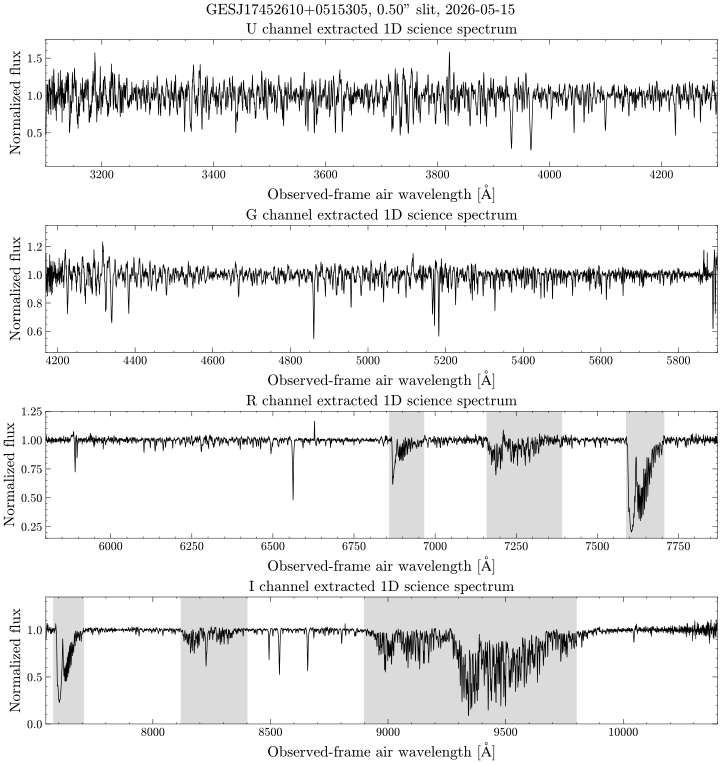

In [4]:
sci_fig, sci_axes = plot_science_spectra_ugri(observed_spectra)
science_figure_path = repo_dir / "output_plots" / "tutorial_figure_01_full_channel_spectra_UGRI"
sci_fig.savefig(science_figure_path.with_suffix(".png"), dpi=200, bbox_inches="tight")
sci_fig.savefig(science_figure_path.with_suffix(".pdf"), bbox_inches="tight")
plt.show()

## RV Pipeline

The pipeline separates RV measurement into two linked problems: (1) measurement of the wavelength-dependent flexure correction and (2) measurement of the stellar RV after applying that correction. For R-band or I-band spectra, telluric absorption features are used as the default source for measuring flexure corrections, with telluric emission lines available as a fallback option. For G-band spectra, flexure is measured from the strong Oxygen sky-emission line at 5577 Angstroms, as no strong telluric absorption features exist.

In [5]:
# Measure flexure-corrected RVs for example standard star (further description below)
g_emission = measure_ngps_rv(
    observed_spectra["G"],
    template_wavelength,
    template_flux,
    flexure_source="emission",
)

r_telluric = measure_ngps_rv(
    observed_spectra["R"],
    template_wavelength,
    template_flux,
    flexure_source="absorption",
)

r_emission = measure_ngps_rv(
    observed_spectra["R"],
    template_wavelength,
    template_flux,
    flexure_source="emission",
)

i_telluric = measure_ngps_rv(
    observed_spectra["I"],
    template_wavelength,
    template_flux,
    flexure_source="absorption",
)

i_emission = measure_ngps_rv(
    observed_spectra["I"],
    template_wavelength,
    template_flux,
    flexure_source="emission",
)

results = {"G": g_emission, "R": r_telluric, "I": i_telluric}
flexure_results = {
    "R telluric absorption": r_telluric,
    "R sky emission": r_emission,
    "I telluric absorption": i_telluric,
    "I sky emission": i_emission,
}
print("Measurements complete.")

Measurements complete.


### Flexure Correction from Telluric Absorption Features

To measure flexure from telluric absorption features, we use the bundled telluric transmission grid generated from the HITRAN2020 molecular spectroscopic database (see tutorial [here](https://github.com/pranav-nagarajan/DBSP-Flexure-Corrections)). The pipeline selects the telluric model with the closest available airmass and degrades it to the resolution of the observed spectrum. We identify windows with strong telluric absorption features. We assume that the continuum-normalized observed flux $F_{\rm obs}(\lambda)$ in each telluric window is described by a local multiplicative model:

$$
F_{\rm obs}(\lambda) \approx C(\lambda)\,\left[1 + a_\star\left(S\!\left[\lambda; v_\star - v_{\rm bary} + v_{\rm flex}(\lambda_{\rm win})\right] - 1\right)\right]\,\left[1 + a_T\left(T\!\left[\lambda; v_{\rm flex}(\lambda_{\rm win})\right] - 1\right)\right].
$$

Here, $\lambda_{\rm win}$ is the central wavelength of the window, $C(\lambda)$ is a low-order continuum correction, $S$ is the degraded stellar template, $T$ is the degraded telluric transmission template at the nearest grid airmass, $v_\star$ is the stellar RV, $v_{\rm bary}$ is the barycentric correction, and $v_{\rm flex}(\lambda_{\rm win})$ is the local flexure correction evaluated at the central wavelength. The fitted nuisance parameters $a_\star$ and $a_T$ scale the apparent depths of the stellar and telluric features, respectively. We derive the local flexure correction anchored at $\lambda_{\rm win}$ by minimizing the normalized residuals in a least-squares fit. 

Keen readers will notice that the local multiplicative model requires an initial guess for the stellar RV. When no user-supplied guess is available, the pipeline derives a flexure curve based on telluric emission lines in the R and I bands (see the next section), and measures a preliminary stellar RV using that flexure correction. This preliminary RV is then used to place the stellar template in the observer frame before fitting the telluric absorption features in the observed spectrum.

The panels below show the Oxygen B band in the R channel and the Oxygen A band in the I channel. The red curve is the best-fit multiplicative model after the local flexure correction has been applied.

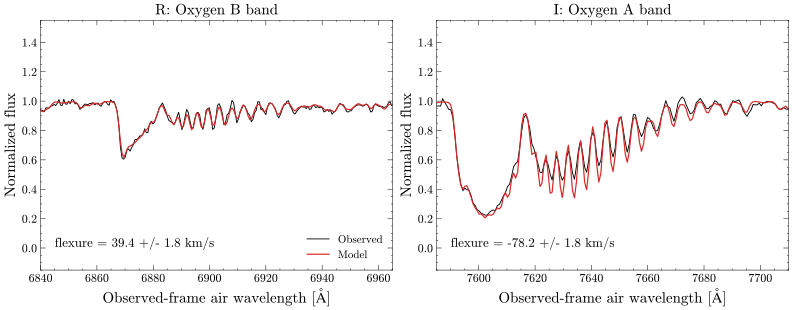

In [6]:
def make_diagnostic_chunk(result, low, high, rv=None):
    mid = 0.5 * (low + high)
    flexure = evaluate_telluric_flexure_curve(
        mid,
        result.flexure_curve,
        fallback_flexure=np.nanmedian(result.flexure_curve["Flexure Correction"]),
        poly_degree=None,
    )
    flexure_error = evaluate_flexure_error(result, mid)
    return pd.Series(
        {
            "Wavelength Min": low,
            "Wavelength Max": high,
            "Wavelength Mid": mid,
            "Flexure Correction": float(flexure),
            "Flexure Correction Error": float(flexure_error),
            "RV": result.rv if rv is None else rv,
        }
    )


def evaluate_flexure_error(result, wavelength):
    table = result.flexure_curve.copy()
    if "Good" in table:
        table = table[table["Good"].fillna(False).astype(bool)]
    if "Flexure Correction Error" not in table or len(table) == 0:
        return np.nan
    x = table["Wavelength"].astype(float).values if "Wavelength" in table else table["Air Wavelength [A]"].astype(float).values
    y = table["Flexure Correction Error"].astype(float).values
    good = np.isfinite(x) & np.isfinite(y)
    if not np.any(good):
        return np.nan
    order = np.argsort(x[good])
    return np.interp(float(wavelength), x[good][order], y[good][order], left=y[good][order][0], right=y[good][order][-1])


def plot_model_overlay(
    ax,
    fits_file,
    result,
    chunk,
    title,
    *,
    y_limits=(0.0, 1.35),
    continuum_degree="rv",
    normalize_model_for_display=True,
):
    diagnostic = chunk_model_diagnostic(
        fits_file,
        result,
        template_wavelength,
        template_flux,
        chunk,
        max_telluric_absorption=0.03,
        continuum_degree=continuum_degree,
        normalize_model_for_display=normalize_model_for_display,
    )
    wavelength = diagnostic["wavelength"]
    in_chunk = diagnostic["chunk_mask"]
    ax.plot(wavelength[in_chunk], diagnostic["observed"][in_chunk], color="black", linewidth=0.9, label="Observed")
    ax.plot(wavelength[in_chunk], diagnostic["multiplicative_model"][in_chunk], color="tab:red", linewidth=1.2, label="Model")
    ax.set_xlim(float(chunk["Wavelength Min"]), float(chunk["Wavelength Max"]))
    ax.set_ylim(*y_limits)
    ax.set_title(title)
    ax.set_xlabel(r"Observed-frame air wavelength [$\mathrm{\AA}$]")
    ax.set_ylabel("Normalized flux")
    return diagnostic

flexure_examples = [
    (observed_spectra["R"], r_telluric, make_diagnostic_chunk(r_telluric, 6840, 6965), "R: Oxygen B band"),
    (observed_spectra["I"], i_telluric, make_diagnostic_chunk(i_telluric, 7585, 7710), "I: Oxygen A band"),
]

tell_absorption_fig, axes = plt.subplots(1, 2, figsize=(11, 4.3), constrained_layout=True)
for ax, (fits_file, result, chunk, title) in zip(axes, flexure_examples):
    diagnostic = plot_model_overlay(
        ax,
        fits_file,
        result,
        chunk,
        title,
        y_limits=(-0.15, 1.55),
        continuum_degree=1,
        normalize_model_for_display=False,
    )
    ax.text(
        0.04,
        0.08,
        f"flexure = {diagnostic['flexure_correction']:.1f} +/- {chunk['Flexure Correction Error']:.1f} km/s",
        transform=ax.transAxes,
        ha="left",
        va="bottom",
        fontsize=13,
    )
axes[0].legend(loc="lower right")
telluric_overlay_path = repo_dir / "output_plots" / "tutorial_figure_02_telluric_model_overlays"
tell_absorption_fig.savefig(telluric_overlay_path.with_suffix(".png"), dpi=200, bbox_inches="tight")
tell_absorption_fig.savefig(telluric_overlay_path.with_suffix(".pdf"), bbox_inches="tight")
plt.show()

### Flexure Correction from Telluric Emission Features

For spectra with low signal-to-noise ratios, telluric absorption features may be too weak or too sparse to use the method above. In that case, as a fallback option, it is possible to measure flexure from telluric emission lines in the G, R, or I bands. In detail, the code identifies strong emission lines in the specified channel based on the atlas of Hanuschik (2003), enforcing a minimum separation to avoid multiplets. Each emission line is then fit locally with a Gaussian model:

$$
F_{\rm sky}(\lambda) \approx b_0 + b_1(\lambda - \lambda_0) + A\exp\left[-\frac{(\lambda - \lambda_c)^2}{2\sigma^2}\right],
$$

where $F_{\rm sky}$ is the 1D sky model extracted at the location of the science trace, $b_0$ and $b_1$ describe the local continuum, $A$ is the line amplitude, $\lambda_c$ is the fitted centroid, and $\sigma$ is the line width. The sky spectrum is extracted with the same boxcar aperture as the science spectrum, centered on the same spatial trace pixel. Given the tabulated emission-line wavelength $\lambda_{\rm ref}$, the line centroid offset is then converted to a flexure correction:

$$
v_{\rm flex} = c\,\frac{\lambda_c - \lambda_{\rm ref}}{\lambda_{\rm ref}}.
$$

The extracted 1D sky spectra below show the telluric emission lines in each channel, with the fitted emission lines identified by red markers. Not all of the emission lines are marked, because several lines in the catalog are filtered out by the strength and separation cuts. The U band has no useful emission features, and the G band is dominated by the strong 5577 Angstrom Oxygen line. On the other hand, the R and I bands have several strong sky lines, with the telluric emission features becoming stronger at redder wavelengths.

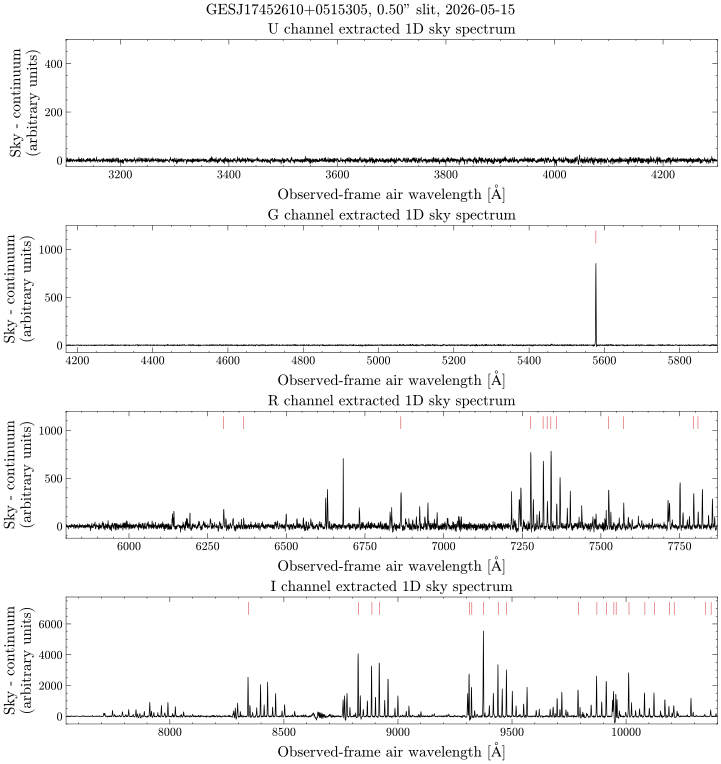

In [7]:
sky_fig, sky_axes = plot_sky_emission_spectra_ugri(observed_spectra)
sky_figure_path = repo_dir / "output_plots" / "tutorial_figure_sky_emission_spectra_UGRI"
sky_fig.savefig(sky_figure_path.with_suffix(".png"), dpi=200, bbox_inches="tight")
sky_fig.savefig(sky_figure_path.with_suffix(".pdf"), bbox_inches="tight")
plt.show()

An example fit to the strong Oxygen emission line at 5577 Angstroms in the G band is shown below.

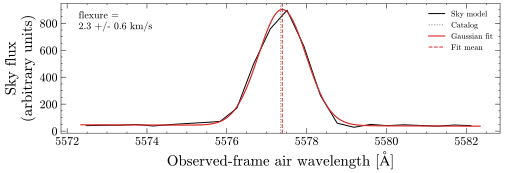

In [8]:
sky_fit_fig, axes = plot_emission_line_fits(observed_spectra["G"], g_emission, max_lines=1)
axes = np.atleast_1d(axes).ravel()
for ax in axes:
    ax.tick_params(labelsize=12)
    ax.set_xlabel(ax.get_xlabel(), fontsize=15)
    ax.set_ylabel(ax.get_ylabel(), fontsize=15)
emission_fit_path = repo_dir / "output_plots" / "tutorial_figure_03_g_emission_line_fit"
sky_fit_fig.savefig(emission_fit_path.with_suffix(".png"), dpi=200, bbox_inches="tight")
sky_fit_fig.savefig(emission_fit_path.with_suffix(".pdf"), bbox_inches="tight")
plt.show()

### Flexure Curves

The wavelengths at which local flexure corrections are derived are termed "anchors." To create a flexure curve, the pipeline linearly interpolates between anchors. Outside of the supported wavelength range, the flexure is "clamped" to the value at the nearest edge. If only one usable anchor is available, that single flexure correction is used across the channel.

The four panels below show example telluric-absorption and telluric-emission flexure curves derived in the R and I channels for the same standard star. Blue points represent the flexure anchors, black curves show the flexure curve evaluated between or beyond the anchors, and orange crosses show where the flexure curve is evaluated for the wavelength chunks used to measure the stellar RV (see the following section).

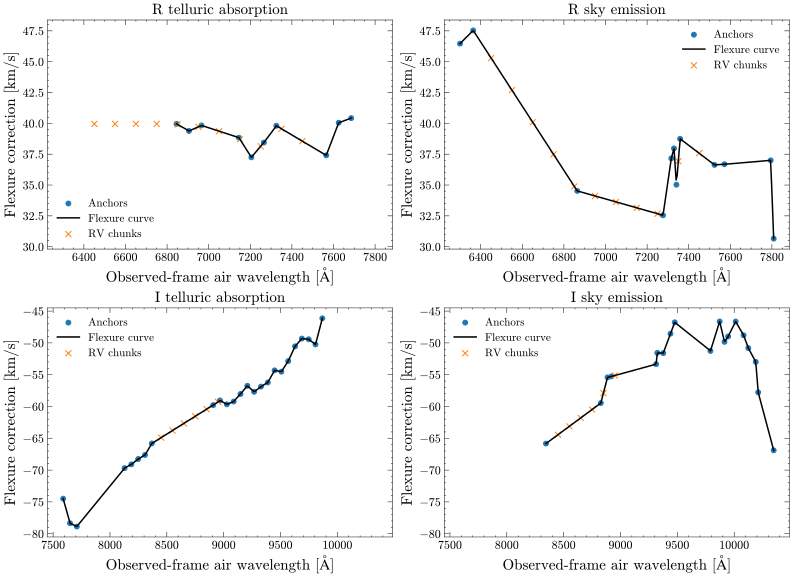

In [9]:
flex_curve_fig, axes = plt.subplots(2, 2, figsize=(11, 8), constrained_layout=True, sharex="row", sharey=False)
for ax, (label, result) in zip(axes.ravel(), flexure_results.items()):
    plot_flexure_curve(result, ax=ax, simple=True)
    ax.set_title(label)
    ax.set_ylabel("Flexure correction [km/s]")

for row_axes in axes:
    row_ymin = min(ax.get_ylim()[0] for ax in row_axes)
    row_ymax = max(ax.get_ylim()[1] for ax in row_axes)
    for ax in row_axes:
        ax.set_ylim(row_ymin, row_ymax)

handles, labels = axes[0, 0].get_legend_handles_labels()
axes[0, 0].legend(handles, labels, loc="lower left")

flexure_figure_path = repo_dir / "output_plots" / "Flexure_Correction_Curves_RI"
flex_curve_fig.savefig(flexure_figure_path.with_suffix(".png"), dpi=200, bbox_inches="tight")
flex_curve_fig.savefig(flexure_figure_path.with_suffix(".pdf"), bbox_inches="tight")
plt.show()

The corresponding tables, representing the derived wavelength-dependent flexure corrections, are displayed below.

In [10]:
def compact_flexure_table(result):
    table = result.flexure_curve.copy()
    if "Good" in table:
        table = table[table["Good"].fillna(False).astype(bool)]
    wavelength_column = "Wavelength" if "Wavelength" in table else "Air Wavelength [A]"
    columns = [wavelength_column, "Flexure Correction", "Flexure Correction Error"]
    columns = [col for col in columns if col in table.columns]
    output = table[columns].copy()
    if wavelength_column == "Wavelength":
        output[wavelength_column] = convert_vacuum_to_air(output[wavelength_column].values.astype(float))
    output = output.rename(
        columns={
            wavelength_column: "Observed-frame air wavelength [Å]",
            "Flexure Correction": "Flexure [km/s]",
            "Flexure Correction Error": "Error [km/s]",
        }
    ).reset_index(drop=True)
    return output

for label, result in flexure_results.items():
    display(Markdown(f"**{label}**"))
    display(compact_flexure_table(result).round(3))

**R telluric absorption**

,Observed-frame air wavelength [Å],Flexure [km/s],Error [km/s]
0,6845.296,39.960,1.691
1,6905.280,39.386,1.775
2,6965.264,39.833,2.036
3,7145.216,38.842,1.737
4,7205.199,37.247,1.712
5,7265.183,38.443,1.700
6,7325.167,39.807,1.491
7,7565.102,37.406,5.141
8,7625.086,40.052,3.150
9,7685.070,40.426,1.603


**R sky emission**

,Observed-frame air wavelength [Å],Flexure [km/s],Error [km/s]
0,6300.309,46.464,3.011
1,6363.783,47.536,5.723
2,6863.971,34.523,2.134
3,7276.424,32.547,1.086
4,7316.290,37.162,1.088
5,7329.160,37.970,2.152
6,7340.901,35.027,1.110
7,7358.680,38.747,1.693
8,7524.007,36.633,1.140
9,7571.751,36.683,2.149


**I telluric absorption**

,Observed-frame air wavelength [Å],Flexure [km/s],Error [km/s]
0,7588.374,-74.493,2.854
1,7648.358,-78.352,1.755
2,7708.342,-78.876,4.015
3,8128.229,-69.691,0.649
4,8188.212,-69.101,0.909
5,8248.196,-68.256,0.678
6,8308.180,-67.622,0.743
7,8368.164,-65.807,1.322
8,8908.018,-59.787,1.162
9,8968.001,-59.043,0.666


**I sky emission**

,Observed-frame air wavelength [Å],Flexure [km/s],Error [km/s]
0,8344.613,-65.831,1.240
1,8827.112,-59.458,1.226
2,8885.856,-55.419,0.981
3,8919.637,-55.276,0.798
4,9313.346,-53.343,1.292
5,9323.763,-51.572,1.199
6,9375.977,-51.612,1.290
7,9439.670,-48.552,0.857
8,9476.895,-46.767,0.639
9,9791.116,-51.264,1.706


### Stellar RV Measurement

To measure the stellar RV, the observed spectrum is broken into wavelength chunks of equal length. By default, the R-band fit uses 100 Å chunks from 6400-7500 Å, while the I-band fit uses 100 Å chunks from 8400-9000 Å. Within each chunk, pixels where the shifted telluric model predicts strong atmospheric absorption are masked. Then, for a trial template shift $v$, the chi-squared metric $\chi^2(v)$ is evaluated as:

$$
\chi^2(v) = \sum_i \frac{\left[f_i - S_i(v)\right]^2}{\sigma_i^2}.
$$

where $f_i$ is the normalized observed flux in pixel $i$, $S_i(v)$ is the degraded stellar-template flux shifted by trial velocity $v$, and $\sigma_i$ is the normalized flux uncertainty. The best template shift is

$$
v_{\rm best\ template\ shift} = \underset{v}{\arg\min}\;\chi^2(v).
$$

The error on this RV is based on the width of the minimum, i.e., the velocity interval over which the $\chi^2$ statistic changes by one.

Let $\lambda_{\rm chunk}$ be the wavelength at the center of a given chunk. To correct for flexure, the derived flexure curve is evaluated at this wavelength, producing a shift $v_{\rm flex}({\lambda_{\rm chunk}})$. The reported chunk RV is also corrected for the Earth's barycenter motion $v_{\rm bary}$, as the NGPS QuickLook DRP does not apply this correction by default:

$$
v_{\rm chunk} = \underset{v}{\arg\min}\;\chi^2(v) - v_{\rm flex}(\lambda_{\rm chunk}) + v_{\rm bary}.
$$

The individual chunk RVs are robustly combined after quality cuts and outlier rejection to produce a final stellar RV measurement.

Below, we compare the observed spectrum and shifted [BOSZ stellar template](https://archive.stsci.edu/hlsp/bosz) in wavelength chunks containing H alpha and the Ca triplet. In these chunks, there are no telluric-rejected pixels, implying that the observed spectra are dominated by stellar features. The chi-squared curves corresponding to the overlays are shown as well; the annotated RVs are the final chunk RVs after applying the flexure and barycentric corrections.

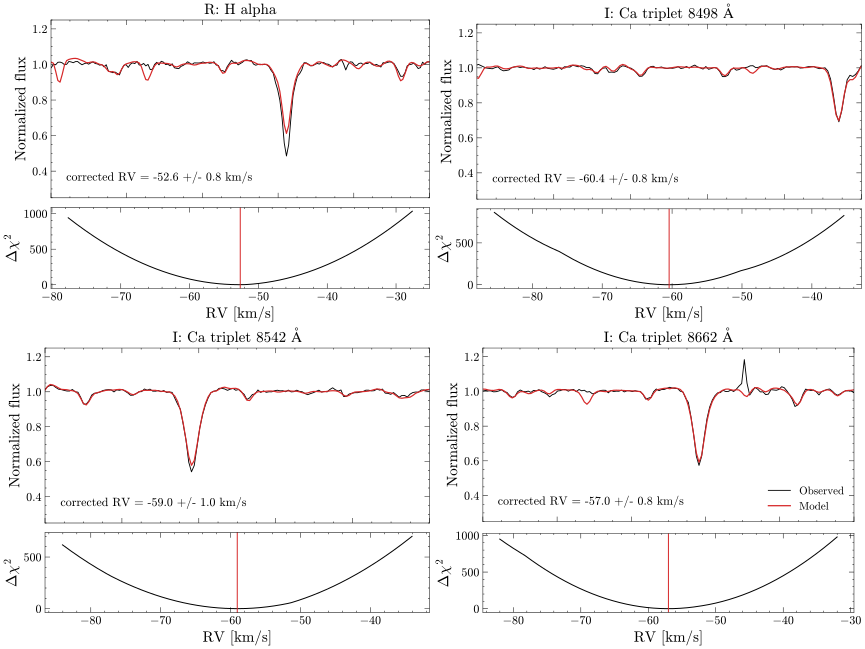

In [11]:
def nearest_chunk(result, center):
    table = result.chunk_rvs.copy()
    if "Use in Combined RV" in table:
        used = table[table["Use in Combined RV"].fillna(False).astype(bool)]
        if len(used):
            table = used
    idx = np.nanargmin(np.abs(table["Wavelength Mid"].astype(float).values - center))
    return table.iloc[idx]

rv_examples = [
    (observed_spectra["R"], r_telluric, nearest_chunk(r_telluric, 6550), "R: H alpha"),
    (observed_spectra["I"], i_telluric, nearest_chunk(i_telluric, 8450), r"I: Ca triplet 8498 $\mathrm{\AA}$"),
    (observed_spectra["I"], i_telluric, nearest_chunk(i_telluric, 8550), r"I: Ca triplet 8542 $\mathrm{\AA}$"),
    (observed_spectra["I"], i_telluric, nearest_chunk(i_telluric, 8650), r"I: Ca triplet 8662 $\mathrm{\AA}$"),
]

chunk_fig = plt.figure(figsize=(12, 9), constrained_layout=True)
outer = chunk_fig.add_gridspec(2, 2)
for index, (fits_file, result, chunk, title) in enumerate(rv_examples):
    inner = outer[index // 2, index % 2].subgridspec(2, 1, height_ratios=[2.2, 1.0], hspace=0.03)
    ax_spec = chunk_fig.add_subplot(inner[0])
    ax_chi = chunk_fig.add_subplot(inner[1])
    diagnostic = plot_model_overlay(
        ax_spec,
        fits_file,
        result,
        chunk,
        title,
        y_limits=(0.25, 1.25),
        continuum_degree="rv",
        normalize_model_for_display=True,
    )
    ax_spec.tick_params(labelbottom=False)
    ax_spec.set_xlabel("")
    ax_spec.text(
        0.04,
        0.08,
        f"corrected RV = {diagnostic['rv']:.1f} +/- {float(chunk['RV Error']):.1f} km/s",
        transform=ax_spec.transAxes,
        ha="left",
        va="bottom",
        fontsize=12,
    )

    rv_grid, chi2 = chunk_chi2_curve(
        fits_file,
        result,
        template_wavelength,
        template_flux,
        chunk,
        rv_half_width=25,
        rv_step=0.25,
    )
    finite = np.isfinite(chi2)
    if np.any(finite):
        ax_chi.plot(rv_grid[finite], chi2[finite] - np.nanmin(chi2[finite]), color="black", linewidth=1.0)
    ax_chi.axvline(float(chunk["RV"]), color="tab:red", linewidth=1.0)
    ax_chi.set_xlabel("RV [km/s]")
    ax_chi.set_ylabel(r"$\Delta \chi^2$")
ax_spec.legend(loc="lower right")
chunk_figure_path = repo_dir / "output_plots" / "tutorial_figure_05_rv_chunk_chi2_examples"
chunk_fig.savefig(chunk_figure_path.with_suffix(".png"), dpi=200, bbox_inches="tight")
chunk_fig.savefig(chunk_figure_path.with_suffix(".pdf"), bbox_inches="tight")
plt.show()

For this example standard star, the RV reported in the Gaia-ESO catalog is -60.32 km/s. We report our final measured RVs in the G, R, and I channels below. For the R and I channels, we report RV measurements based on both telluric absorption and emission lines, though we recommend using the telluric absorption features as the flexure source. From the catalog residuals, we see that our RV measurements agree with the known RV to within $2\sigma$ in all cases. The recommended RV precision to adopt for a science target is $\lesssim5$ km s$^{-1}$.

In [12]:
rv_summary = pd.DataFrame(
    [
        {
            "Channel": "G",
            "Flexure source": "sky emission",
            "RV [km/s]": g_emission.rv,
            "RV error [km/s]": g_emission.rv_error,
            "Catalog residual [km/s]": g_emission.rv - catalog_rv_kms,
        },
        {
            "Channel": "R",
            "Flexure source": "telluric absorption",
            "RV [km/s]": r_telluric.rv,
            "RV error [km/s]": r_telluric.rv_error,
            "Catalog residual [km/s]": r_telluric.rv - catalog_rv_kms,
        },
        {
            "Channel": "R",
            "Flexure source": "sky emission",
            "RV [km/s]": r_emission.rv,
            "RV error [km/s]": r_emission.rv_error,
            "Catalog residual [km/s]": r_emission.rv - catalog_rv_kms,
        },
        {
            "Channel": "I",
            "Flexure source": "telluric absorption",
            "RV [km/s]": i_telluric.rv,
            "RV error [km/s]": i_telluric.rv_error,
            "Catalog residual [km/s]": i_telluric.rv - catalog_rv_kms,
        },
        {
            "Channel": "I",
            "Flexure source": "sky emission",
            "RV [km/s]": i_emission.rv,
            "RV error [km/s]": i_emission.rv_error,
            "Catalog residual [km/s]": i_emission.rv - catalog_rv_kms,
        },
    ]
)
display(rv_summary.round(2))


,Channel,Flexure source,RV [km/s],RV error [km/s],Catalog residual [km/s]
0,G,sky emission,-58.50,3.02,1.82
1,R,telluric absorption,-59.60,4.43,0.72
2,R,sky emission,-56.20,3.58,4.12
3,I,telluric absorption,-59.08,1.44,1.24
4,I,sky emission,-60.18,1.44,0.14


## Applying This To Your Own Spectrum

Replace the example FITS path and template arrays with your observed spectrum and template.

In [13]:
# Example pattern for a user's own observed spectrum and template.
# science_result = measure_ngps_rv(
#     "my_reduced_science_spectrum.fits",
#     my_template_wavelength,
#     my_template_flux,
# )
# print(science_result.rv, science_result.rv_error)

# Some optional controls:
# rv_bounds=(6400, 6600)        # choose a custom stellar RV fitting window
# flexure_source="emission"     # override the automatic flexure-source choice
# emission_line_dir="my_tables" # use custom sky-emission line tables

## Command-Line Wrapper

The same measurement can be run from a terminal with `run_ngps_rv.py`. The input template spectrum can either be a BOSZ file or a file with two columns for wavelength and flux. The wrapper prints the RV and saves a summary table, a simplified flexure curve table, a simplified RV chunk table, and diagnostic PNGs to the specified output folder.

In [14]:
# Example terminal command:
# python run_ngps_rv.py observed_spectra/spec2d_ngps_260515_0087_R.fits \
#     template_spectra/bosz2024_mp_t6000_g+4.0_m+0.00_a+0.00_c+0.00_v2_r5000_resam.txt.gz \
#     --output-dir example_rv_output

# Optional: add --flexure-source absorption or --flexure-source emission to override auto.
# Optional: add --stellar-rv-guess RV_GUESS to add an RV prior.
# Optional: add --flux-error my_flux_errors.txt to use your own flux errors.

## Batch Validation

The validation figure below summarizes the performance of the command-line wrapper on all Gaia-ESO RV standards observed during our NGPS campaign. Each column corresponds to an NGPS channel and each row corresponds to an observing-night/slit-width combination. In every subplot, the upper panel compares the measured RV to the Gaia-ESO catalog RV, while the lower panel shows the residual relative to the catalog value. The upper panel also reports the median absolute RV residual for that batch test. In the residual panels, the error bars represent the uncertainties in the pipeline RV and the Gaia-ESO catalog value added in quadrature.

In making these plots, we use the same defaults as described above: flexure is measured from the 5577 Angstrom telluric emission line in the G band, and from telluric absorption features in the R and I bands. U-band spectra are omitted because they do not contain strong telluric features. Note that NGPS operated in 2-channel mode in 2025, and in 4-channel mode in 2026.

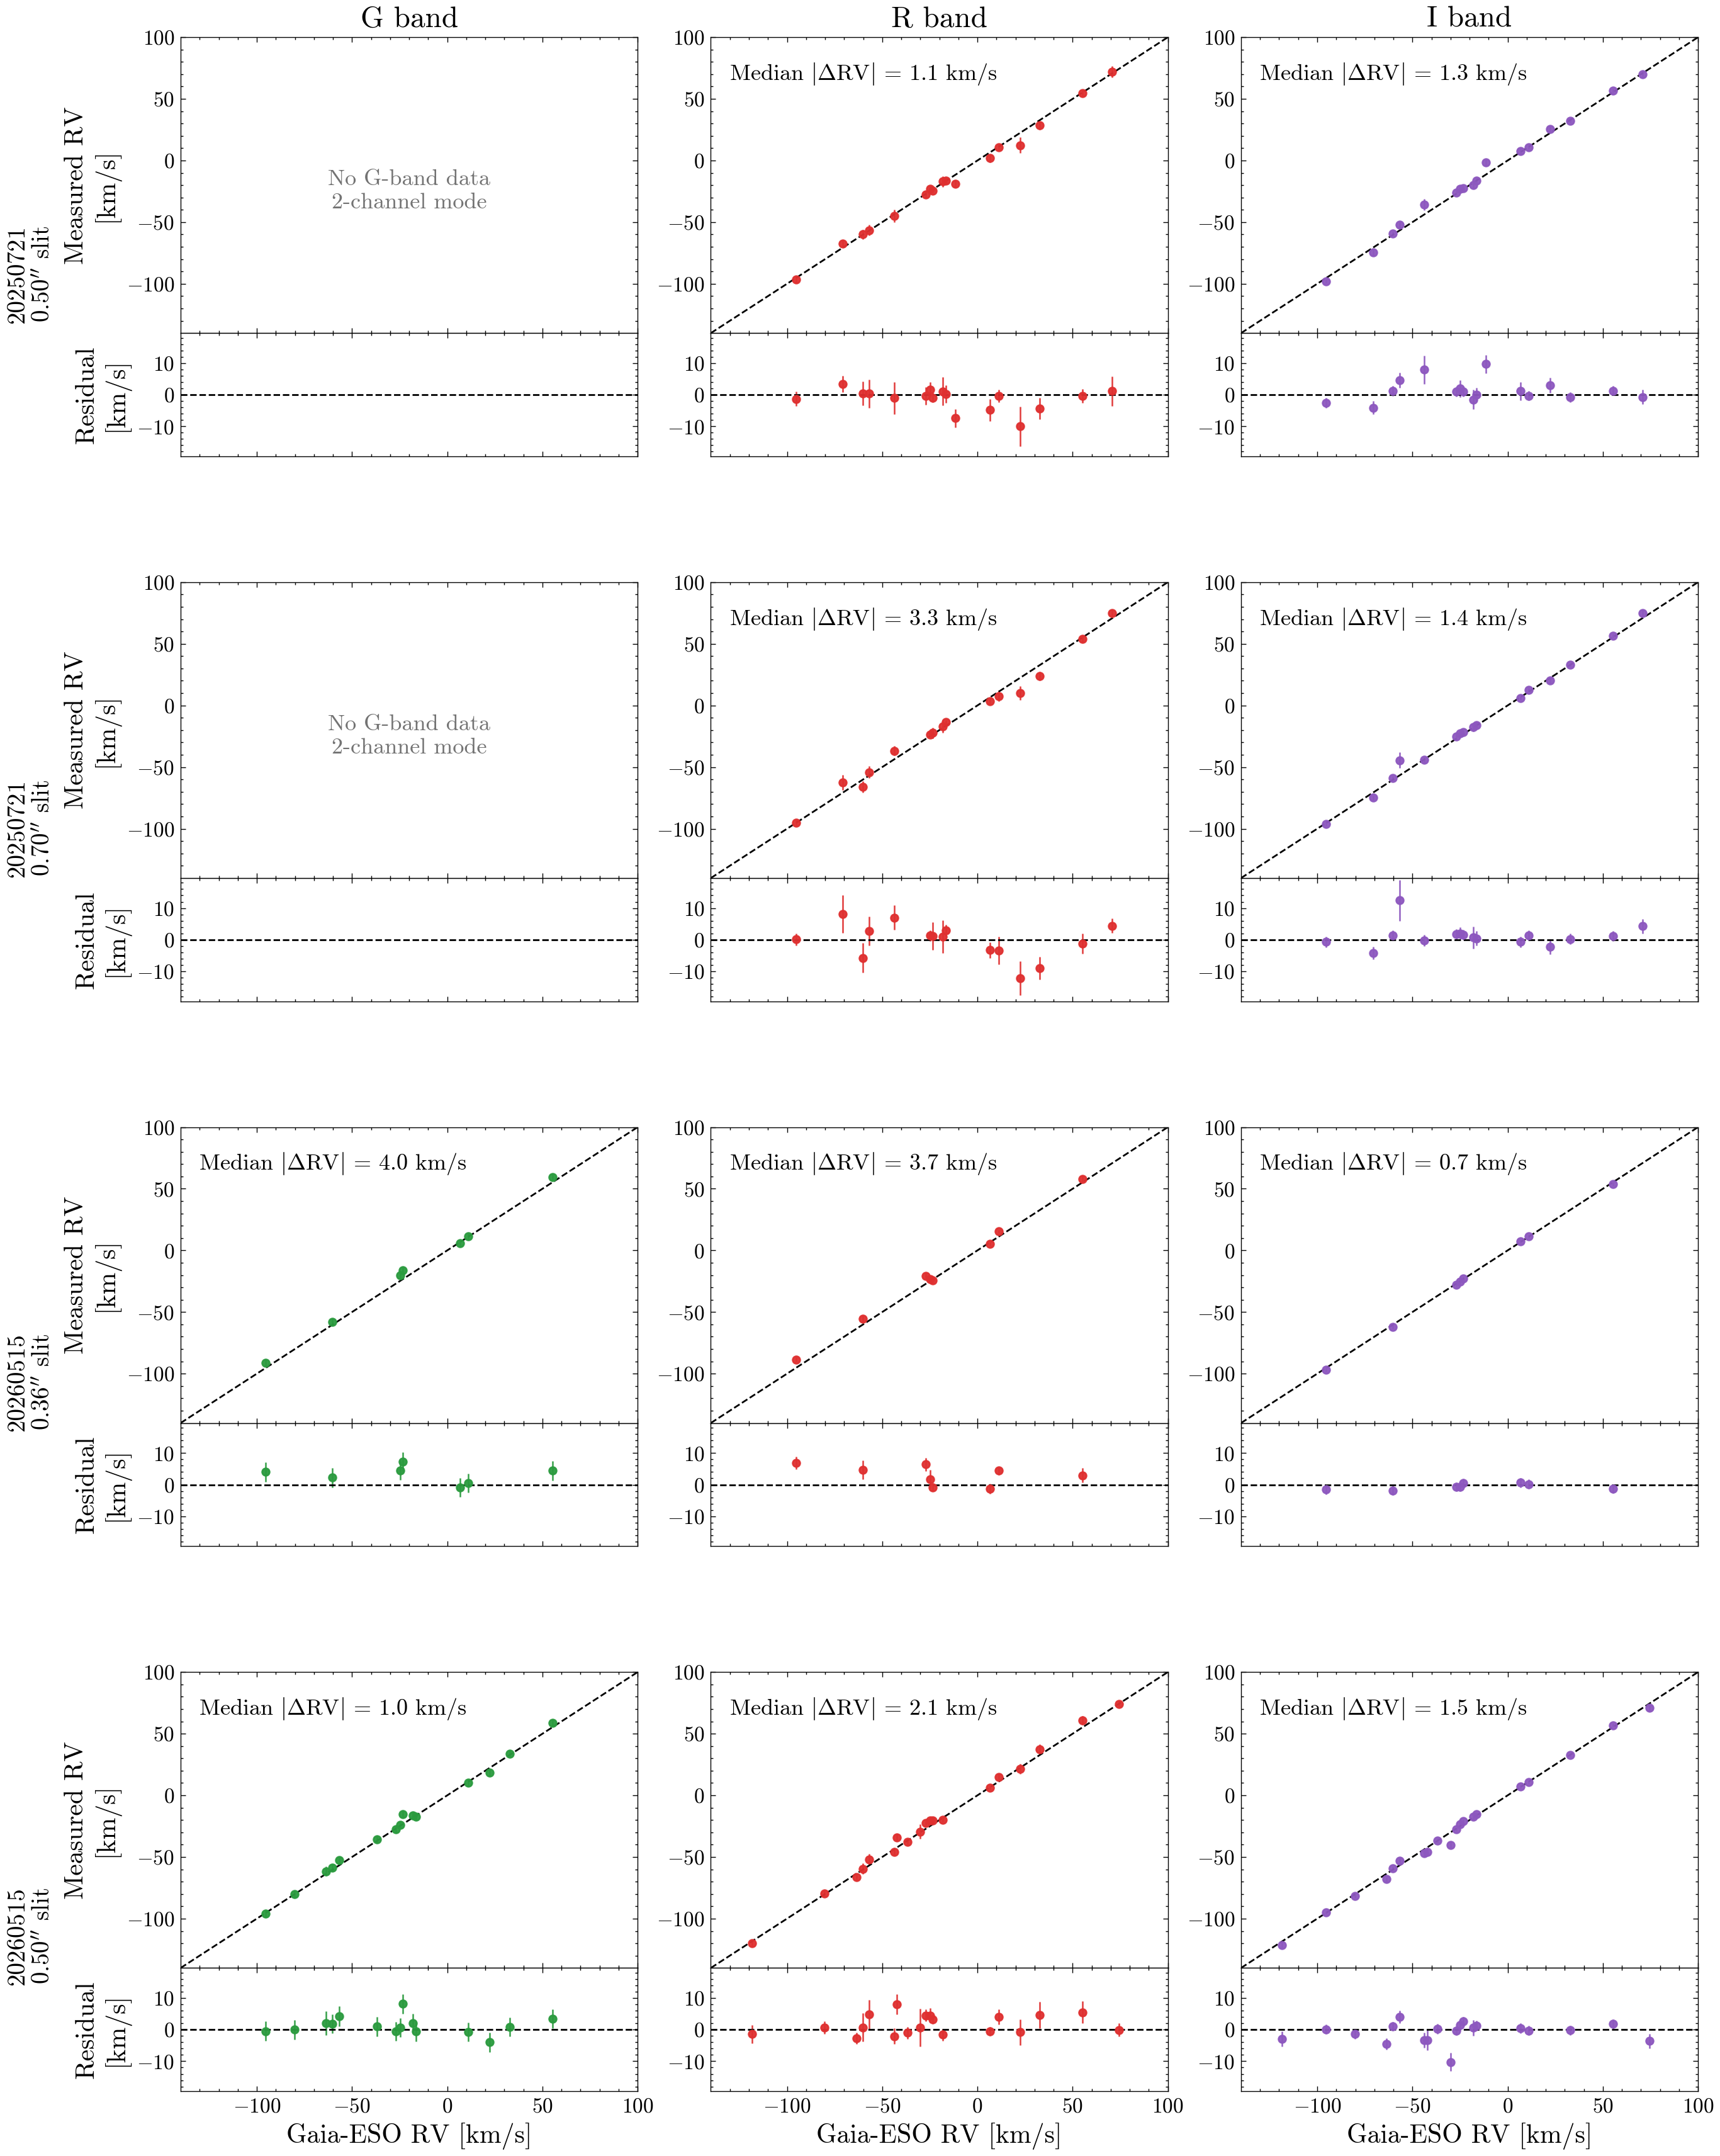

In [15]:
display(Image(filename=repo_dir / "output_plots" / "RV_Batch_Comparison_AutoSeed_BySetup.png"))